In [ ]:
# 屈服强度模型分析

In [10]:
import pandas as pd
import numpy as np
import joblib
import xgboost as xgb
from collections import defaultdict

def collect_root_node_info(model_path, feature_names):
    # 加载模型
    with open(model_path, 'rb') as file:
        model = joblib.load(file)

    root_node_info = []

    if isinstance(model, xgb.XGBRegressor):
        # XGBoost 模型
        booster = model.get_booster()
        dump = booster.get_dump(with_stats=True)
        for idx, tree in enumerate(dump):
            tree_lines = tree.split('\n')
            for line in tree_lines:
                if line.startswith('0:'):
                    root_line = line
                    break
            if 'leaf' not in root_line:
                feature_index_str = root_line.split('[')[1].split('<')[0].strip('f')
                try:
                    feature_index = int(feature_index_str)
                    name = feature_names[feature_index]
                except ValueError:
                    print(f"Warning: Failed to convert feature index '{feature_index_str}' to integer. Skipping this node.")
                    continue
                
                threshold = float(root_line.split('<')[1].split(']')[0])
                left_values = float(root_line.split('gain=')[1].split(',')[0])
                right_values = float(root_line.split('cover=')[1].split(',')[0])

                root_node_info.append({
                    "Model Type": "XGBoost",
                    "Tree Index": idx + 1,
                    "Feature": name,
                    "Threshold": threshold,
                    "Left Child Values": left_values,
                    "Right Child Values": right_values,
                    "Left Greater Than Right": left_values > right_values
                })
    else:
        # Gradient Boosting 模型
        estimators = model.estimators_ if hasattr(model, 'estimators_') else [model]
        for idx, tree in enumerate(estimators):
            if isinstance(tree, np.ndarray):
                tree = tree[0]  # For sklearn ensembles, get the actual tree from the array
            tree_ = tree.tree_
            
            node = 0
            feature_index = tree_.feature[node]
            name = feature_names[feature_index]
            threshold = tree_.threshold[node]
            left_child = tree_.children_left[node]
            right_child = tree_.children_right[node]
            left_values = np.mean(tree_.value[left_child])
            right_values = np.mean(tree_.value[right_child])

            root_node_info.append({
                "Model Type": "Gradient Boosting",
                "Tree Index": idx + 1,
                "Feature": name,
                "Threshold": threshold,
                "Left Child Values": left_values,
                "Right Child Values": right_values,
                "Left Greater Than Right": left_values > right_values
            })

    return root_node_info

def process_models_and_save_to_excel(model_paths, feature_names, file_name):
    all_root_nodes_info = []

    # 遍历所有模型路径，收集根节点信息
    for idx, path in enumerate(model_paths):
        print(f'Processing model {idx + 1} from {path}')
        root_nodes_info = collect_root_node_info(path, feature_names)
        all_root_nodes_info.extend(root_nodes_info)

    # 创建DataFrame并保存到Excel
    df = pd.DataFrame(all_root_nodes_info)
    
    # 计算每个特征的出现频率和平均阈值
    feature_counts = df['Feature'].value_counts().head(5)
    top_features = feature_counts.index
    top_features_info = []
    for feature in top_features:
        feature_df = df[df['Feature'] == feature]
        mean_threshold = feature_df['Threshold'].mean()
        top_features_info.append({
            "Feature": feature,
            "Frequency": feature_counts[feature],
            "Mean Threshold": mean_threshold
        })
    
    # 创建DataFrame并保存到Excel
    top_features_df = pd.DataFrame(top_features_info)
    with pd.ExcelWriter(file_name, engine='openpyxl') as writer:
        df.to_excel(writer, sheet_name='Root Node Info', index=False)
        top_features_df.to_excel(writer, sheet_name='Top Features Info', index=False)

    print(f"Data saved to {file_name}")

# 特征名称列表，需要根据数据集自定义
df = pd.read_excel('qf_models/train_set_new.xlsx', index_col=0)
feature_names = df.drop(columns=['Precipitate Distribution',
       'Habit Plane','Yield_Strength', 'Tensile_Strength (UTS)', '追踪编号']).columns
# 模型路径
gboost_model_paths = [f"qf_models/gboost{index}_new.pkl" for index in [2, 4]]
xgboost_model_paths = [f"qf_models/xgboost{index}_new.pkl" for index in [2, 4]]
all_model_paths = gboost_model_paths + xgboost_model_paths

# 处理模型并保存数据
process_models_and_save_to_excel(all_model_paths, feature_names, "qf_Root_Node_Info.xlsx")


Processing model 1 from qf_models/gboost2_new.pkl
Processing model 2 from qf_models/gboost4_new.pkl
Processing model 3 from qf_models/xgboost2_new.pkl
Processing model 4 from qf_models/xgboost4_new.pkl
Data saved to Root_Node_Info.xlsx


Processing model 1 from kl_models/rf2_new.pkl
Processing model 2 from kl_models/rf4_new.pkl
Processing model 3 from kl_models/xgboost2_new.pkl
Processing model 4 from kl_models/xgboost4_new.pkl
Data saved to kl_Root_Node_Info.xlsx


<Figure size 1400x800 with 0 Axes>

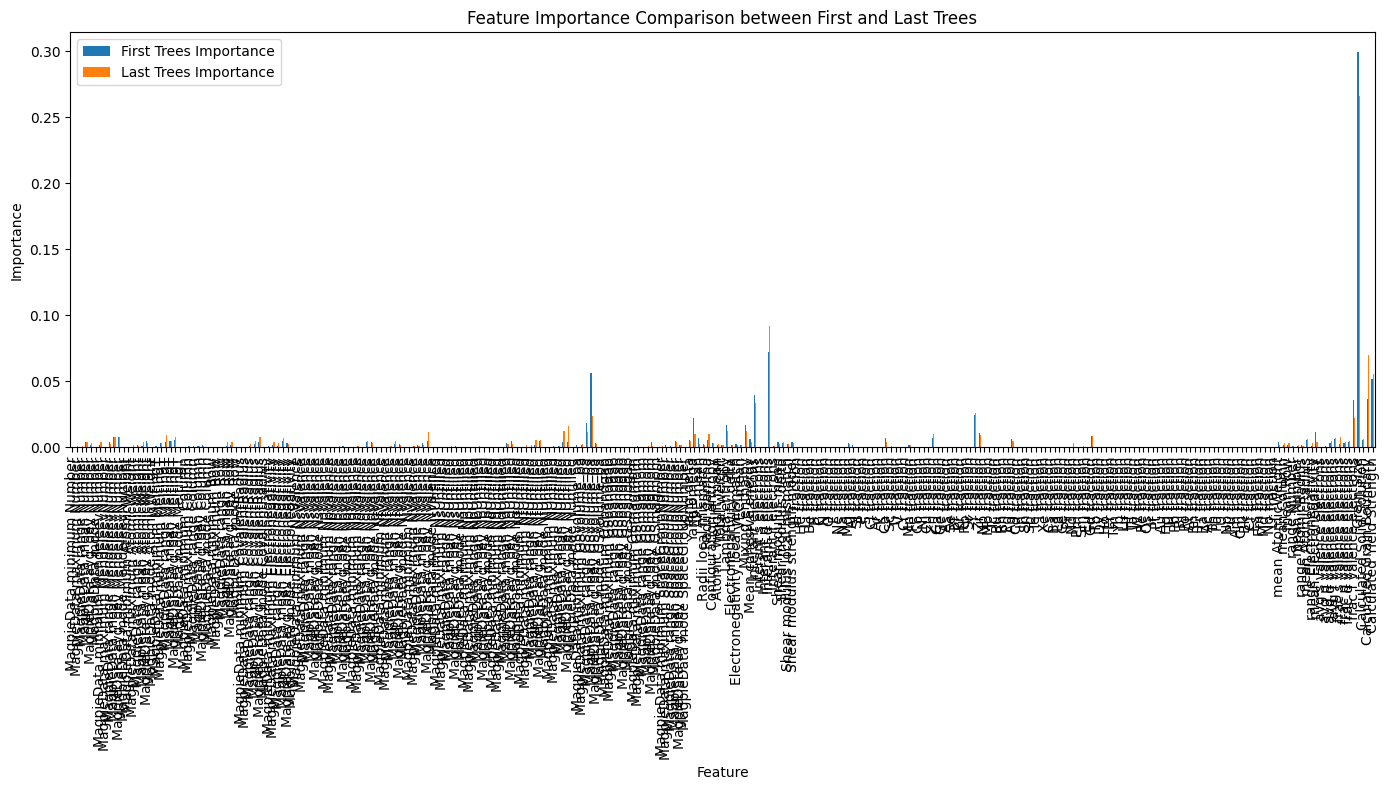

Analysis complete and results saved.


In [20]:
import pandas as pd
import numpy as np
import joblib
import xgboost as xgb
from sklearn.ensemble import RandomForestRegressor
from collections import defaultdict
import matplotlib.pyplot as plt

def collect_root_node_info(model_path, feature_names):
    # 加载模型
    with open(model_path, 'rb') as file:
        model = joblib.load(file)

    root_node_info = []

    if isinstance(model, xgb.XGBRegressor):
        # XGBoost 模型
        booster = model.get_booster()
        dump = booster.get_dump(with_stats=True)
        for idx, tree in enumerate(dump):
            tree_lines = tree.split('\n')
            for line in tree_lines:
                if line.startswith('0:'):
                    root_line = line
                    break
            if 'leaf' not in root_line:
                feature_index_str = root_line.split('[')[1].split('<')[0].strip('f')
                try:
                    feature_index = int(feature_index_str)
                    name = feature_names[feature_index]
                except ValueError:
                    print(f"Warning: Failed to convert feature index '{feature_index_str}' to integer. Skipping this node.")
                    continue
                
                threshold = float(root_line.split('<')[1].split(']')[0])
                left_values = float(root_line.split('gain=')[1].split(',')[0])
                right_values = float(root_line.split('cover=')[1].split(',')[0])

                root_node_info.append({
                    "Model Type": "XGBoost",
                    "Tree Index": idx + 1,
                    "Feature": name,
                    "Threshold": threshold,
                    "Left Child Values": left_values,
                    "Right Child Values": right_values,
                    "Left Greater Than Right": left_values > right_values
                })
    else:
        # Random Forest 模型
        estimators = model.estimators_ if hasattr(model, 'estimators_') else [model]
        for idx, tree in enumerate(estimators):
            if isinstance(tree, np.ndarray):
                tree = tree[0]  # For sklearn ensembles, get the actual tree from the array
            tree_ = tree.tree_
            
            node = 0
            feature_index = tree_.feature[node]
            name = feature_names[feature_index]
            threshold = tree_.threshold[node]
            left_child = tree_.children_left[node]
            right_child = tree_.children_right[node]
            left_values = np.mean(tree_.value[left_child])
            right_values = np.mean(tree_.value[right_child])

            root_node_info.append({
                "Model Type": "Random Forest",
                "Tree Index": idx + 1,
                "Feature": name,
                "Threshold": threshold,
                "Left Child Values": left_values,
                "Right Child Values": right_values,
                "Left Greater Than Right": left_values > right_values
            })

    return root_node_info

def collect_feature_importance(model, feature_names, num_trees):
    feature_importances = defaultdict(list)

    if isinstance(model, xgb.XGBRegressor):
        booster = model.get_booster()
        importance = booster.get_score(importance_type='weight')
        for feature, importance_value in importance.items():
            try:
                feature_index = int(feature.strip('f'))
                feature_importances[feature_names[feature_index]].append(importance_value)
            except ValueError:
                print(f"Warning: Failed to convert feature '{feature}' to integer. Skipping this feature.")
                continue
    else:
        for idx, tree in enumerate(model.estimators_[:num_trees]):
            tree_importance = tree.feature_importances_
            for feature, importance_value in zip(feature_names, tree_importance):
                feature_importances[feature].append(importance_value)
    
    return feature_importances

def process_models_and_save_to_excel(model_paths, feature_names, file_name):
    all_root_nodes_info = []
    all_feature_importances = defaultdict(list)

    # 遍历所有模型路径，收集根节点信息
    for idx, path in enumerate(model_paths):
        print(f'Processing model {idx + 1} from {path}')
        root_nodes_info = collect_root_node_info(path, feature_names)
        all_root_nodes_info.extend(root_nodes_info)

        with open(path, 'rb') as file:
            model = joblib.load(file)
        if isinstance(model, xgb.XGBRegressor):
            num_trees = model.n_estimators
        else:
            num_trees = len(model.estimators_)
        
        feature_importances = collect_feature_importance(model, feature_names, num_trees)
        
        for feature, importances in feature_importances.items():
            all_feature_importances[feature].extend(importances)

    # 创建DataFrame并保存到Excel
    df = pd.DataFrame(all_root_nodes_info)
    
    # 计算每个特征的出现频率和平均阈值
    feature_counts = df['Feature'].value_counts().head(5)
    top_features = feature_counts.index
    top_features_info = []
    for feature in top_features:
        feature_df = df[df['Feature'] == feature]
        mean_threshold = feature_df['Threshold'].mean()
        top_features_info.append({
            "Feature": feature,
            "Frequency": feature_counts[feature],
            "Mean Threshold": mean_threshold
        })
    
    # 创建DataFrame并保存到Excel
    top_features_df = pd.DataFrame(top_features_info)
    with pd.ExcelWriter(file_name, engine='openpyxl') as writer:
        df.to_excel(writer, sheet_name='Root Node Info', index=False)
        top_features_df.to_excel(writer, sheet_name='Top Features Info', index=False)

    print(f"Data saved to {file_name}")

    return all_feature_importances

# 特征名称列表，需要根据数据集自定义
df = pd.read_excel('kl_models/train_set_new.xlsx', index_col=0)
feature_names = df.drop(columns=['Precipitate Distribution',
       'Habit Plane','Yield_Strength', 'Tensile_Strength (UTS)', '追踪编号']).columns

# 模型路径
rf_model_paths = [f"kl_models/rf{index}_new.pkl" for index in [2, 4]]
xgboost_model_paths = [f"kl_models/xgboost{index}_new.pkl" for index in [2, 4]]
all_model_paths = rf_model_paths + xgboost_model_paths

# 处理模型并保存数据
all_feature_importances = process_models_and_save_to_excel(all_model_paths, feature_names, "kl_Root_Node_Info.xlsx")

# 计算前50棵树和后50棵树的平均重要性
def average_importance(importances, num_trees, feature_names):
    avg_importances = {}
    for feature in feature_names:
        first_trees_importance = np.mean(importances[feature][:num_trees])
        last_trees_importance = np.mean(importances[feature][-num_trees:])
        avg_importances[feature] = {
            "First Trees": first_trees_importance,
            "Last Trees": last_trees_importance
        }
    return avg_importances

num_trees = 50
avg_importances = average_importance(all_feature_importances, num_trees, feature_names)

# 将结果保存到Excel文件
avg_importances_df = pd.DataFrame(avg_importances).T.reset_index()
avg_importances_df.columns = ['Feature', 'First Trees Importance', 'Last Trees Importance']
avg_importances_df.to_excel("kl_Feature_Importance_Comparison.xlsx", index=False)

# 绘制前50棵树和后50棵树的重要性比较图
plt.figure(figsize=(14, 8))
avg_importances_df.plot(kind='bar', x='Feature', figsize=(14, 8))
plt.title('Feature Importance Comparison between First and Last Trees')
plt.xlabel('Feature')
plt.ylabel('Importance')
plt.xticks(rotation=90)
plt.tight_layout()
plt.savefig('kl_Feature_Importance_Comparison.png')
plt.show()

print("Analysis complete and results saved.")


In [2]:
import pandas as pd
import numpy as np
import joblib
from collections import defaultdict

def collect_root_node_info(model_path, feature_names):
    # 加载模型
    with open(model_path, 'rb') as file:
        model = joblib.load(file)

    root_node_info = []

    # 遍历模型中的每棵树
    estimators = model.estimators_ if hasattr(model, 'estimators_') else [model]
    for idx, tree in enumerate(estimators):
        tree_ = tree.tree_
        
        node = 0
        # if tree_.feature[node] == tree_.TREE_UNDEFINED:
        #     continue  # 跳过未定义特征的节点
        
        feature_index = tree_.feature[node]
        name = feature_names[feature_index]
        threshold = tree_.threshold[node]
        left_child = tree_.children_left[node]
        right_child = tree_.children_right[node]
        left_values = np.mean(tree_.value[left_child])
        right_values = np.mean(tree_.value[right_child])

        root_node_info.append({
            "Model Type": "Random Forest" if 'rf' in model_path else "Gradient Boosting",
            "Tree Index": idx + 1,
            "Feature": name,
            "Threshold": threshold,
            "Left Child Values": left_values,
            "Right Child Values": right_values,
            "Left Greater Than Right": left_values > right_values
        })

    return root_node_info

def process_models_and_save_to_excel(model_paths, feature_names, file_name):
    all_root_nodes_info = []

    # 遍历所有模型路径，收集根节点信息
    for idx, path in enumerate(model_paths):
        print(f'Processing model {idx + 1} from {path}')
        root_nodes_info = collect_root_node_info(path, feature_names)
        all_root_nodes_info.extend(root_nodes_info)

    # 创建DataFrame并保存到Excel
    df = pd.DataFrame(all_root_nodes_info)
    df.to_excel(file_name, index=False)
    print(f"Data saved to {file_name}")

# 特征名称列表
# 特征名称列表，你需要根据你的数据集自定义这部分
df = pd.read_excel('../Final_Model/Full.xlsx', index_col=0)  # 引入这一列之后，原本的第一列就是一个索引，第0列会从有意义的列开始
# 删除包含空值的行

df = df[df['Yield_Strength'] != 0].reset_index(drop=True)
feature_names = df.columns[:-4]

# 模型路径
rf_model_paths = [f"../Final_Model/models/qf/rf/rf{i}.pkl" for i in range(1, 6)]
gb_model_paths = [f"../Final_Model/models/qf/gboost/gboost{i}.pkl" for i in range(1, 6)]
all_model_paths = rf_model_paths + gb_model_paths

# 处理模型并保存数据
process_models_and_save_to_excel(all_model_paths, feature_names, "Root_Node_Info.xlsx")


Processing model 1 from ../Final_Model/models/qf/rf/rf1.pkl
Processing model 2 from ../Final_Model/models/qf/rf/rf2.pkl
Processing model 3 from ../Final_Model/models/qf/rf/rf3.pkl
Processing model 4 from ../Final_Model/models/qf/rf/rf4.pkl
Processing model 5 from ../Final_Model/models/qf/rf/rf5.pkl
Processing model 6 from ../Final_Model/models/qf/gboost/gboost1.pkl


F:\Anaconda\envs\new_env\lib\site-packages\sklearn\base.py:376: InconsistentVersionWarning: Trying to unpickle estimator DecisionTreeRegressor from version 1.3.0 when using version 1.4.2. This might lead to breaking code or invalid results. Use at your own risk. For more info please refer to:
https://scikit-learn.org/stable/model_persistence.html#security-maintainability-limitations
  warnings.warn(
F:\Anaconda\envs\new_env\lib\site-packages\sklearn\base.py:376: InconsistentVersionWarning: Trying to unpickle estimator RandomForestRegressor from version 1.3.0 when using version 1.4.2. This might lead to breaking code or invalid results. Use at your own risk. For more info please refer to:
https://scikit-learn.org/stable/model_persistence.html#security-maintainability-limitations
  warnings.warn(


ModuleNotFoundError: No module named 'sklearn.ensemble._gb_losses'